In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, auc, roc_auc_score, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import SMOTE
!pip install shap
import shap

### Load data

In [2]:
df = pd.read_csv("C:/Users/Admin/Downloads/Fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

###  Data Cleaning and Preprocessing

In [4]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
"""Why it's useful to have deltaOrig:
#If the result is not zero, it suggests something unusual—either:
   -A mismatch in transaction values
   -An inconsistency in the recorded balances
   -Possibly fraudulent manipulation"""
df['deltaOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['deltaOrig'] = df['deltaOrig'].round(2).abs()#when comparing or using it in the model, it's best to treat these tiny numbers as zero.

"""Why it's useful to have deltaDest:
#Fraudulent transactions often have missing or incorrect balance updates, especially when routing through multiple accounts.
#A large positive or negative delta may indicate:
   -Fake accounts
   -Nonexistent balance
   -A middle account in a fraud chain"""
df['deltaDest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

"""Why it's useful:
#In your dataset, merchants are treated differently (e.g., may have missing balance data).
#Fraudsters may avoid merchant accounts because they are more regulated or harder to exploit.
#Or fraud may target only non-merchants, which makes this a useful categorical discriminator for us."""
df['isMerchantDest'] = df['nameDest'].apply(lambda x: 1 if str(x).startswith('M') else 0)

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,deltaOrig,deltaDest,isMerchantDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,-9839.64,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,-1864.28,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,-181.00,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0.0,-21363.00,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,-11668.14,1


In [7]:
df[df.deltaDest>0].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,deltaOrig,deltaDest,isMerchantDest
10,1,DEBIT,9644.94,C1900366749,4465.00,0.0,C997608398,10845.0,157982.12,0,0,5179.94,137492.18,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.0,2719172.89,0,0,300850.89,2401220.00,0
48,1,CASH_OUT,5346.89,C512549200,0.00,0.0,C248609774,652637.0,6453430.91,0,0,5346.89,5795447.02,0
72,1,CASH_OUT,94253.33,C1718906711,25203.05,0.0,C977993101,99773.0,965870.05,0,0,69050.28,771843.72,0
81,1,TRANSFER,78766.03,C1376151044,0.00,0.0,C1749186397,103772.0,277515.05,0,0,78766.03,94977.02,0


In [8]:
df.groupby('isFraud')['deltaDest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-54692.231734,4.360026e+05,-13191233.98,-29259.805,-3500.68,0.0,75885725.63
1,8213.0,-732509.301069,1.867748e+06,-10000000.00,-442722.010,-2231.46,0.0,8875516.29


<Axes: xlabel='deltaDest', ylabel='Count'>

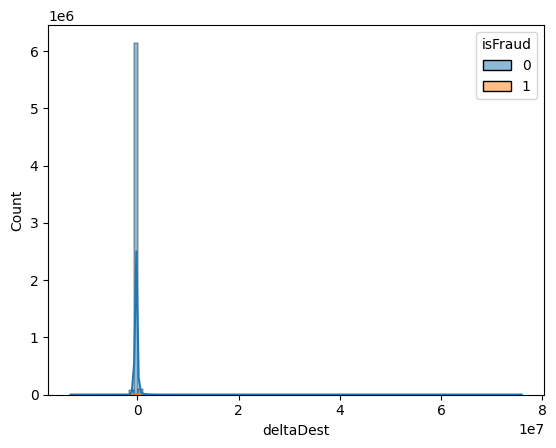

In [9]:
sns.histplot(data=df, x='deltaDest', hue='isFraud', bins=100,kde=True)

### Droping uninformative columns:

In [10]:
df.drop(['nameOrig','nameDest'], axis=1,inplace=True)
df.head(1)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,deltaOrig,deltaDest,isMerchantDest
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,0.0,-9839.64,1


### One-hot encode 'type'

In [11]:
df.type.unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [12]:
df = pd.get_dummies(df,columns=['type'])
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,deltaOrig,deltaDest,isMerchantDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,0.0,-9839.64,1,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0.0,-1864.28,1,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,0.0,-181.00,0,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,0.0,-21363.00,0,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.0,-11668.14,1,False,False,False,True,False


### Select features and target

In [13]:
X = df.drop(['isFraud','isFlaggedFraud'], axis=1)
y = df['isFraud']

### Handle class imbalance with SMOTE
The Problem:
In your fraud detection data, only a tiny fraction of transactions are actually fraudulent (isFraud = 1). Most are non-fraudulent (isFraud = 0).

This creates a problem called class imbalance:

-The model becomes biased toward predicting the majority class (non-fraud).

-It may predict everything as non-fraud just to get a high accuracy 

-but it would miss all the real frauds.

In [14]:
sm = SMOTE(random_state=42)
#X_resemble = your original + synthetic fraud examples
#y_resemble =  your original labels + added 1s
X_resampled,y_resampled= sm.fit_resample(X,y)

In [15]:
X_resampled.shape

(12708814, 14)

In [16]:
y_resampled.shape

(12708814,)

###  Split into train and test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

### Traninig Model

In [18]:
rnd_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rnd_clf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [24]:
y_pred = rnd_clf.predict(X_test)
y_proba = rnd_clf.predict_proba(X_test)[:, 1]

In [26]:
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270882
           1       1.00      1.00      1.00   1270881

    accuracy                           1.00   2541763
   macro avg       1.00      1.00      1.00   2541763
weighted avg       1.00      1.00      1.00   2541763

Confusion Matrix:
 [[1270851      31]
 [     26 1270855]]
ROC AUC: 0.9999999951047581


In [27]:
# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print("PR AUC:", pr_auc)

PR AUC: 0.9999999951032966


In [29]:
# Feature Importance
importances = pd.Series(rnd_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", importances)


Feature Importances:
 deltaOrig         0.371269
oldbalanceOrg     0.139289
newbalanceOrig    0.136983
amount            0.068940
type_TRANSFER     0.053365
type_PAYMENT      0.048345
isMerchantDest    0.044562
deltaDest         0.040164
step              0.023655
newbalanceDest    0.019526
type_CASH_IN      0.019461
type_CASH_OUT     0.018437
oldbalanceDest    0.014829
type_DEBIT        0.001174
dtype: float64


#### What kind of prevention should be adopted while company update its infrastructure?
***Answer***:
When updating infrastructure, companies should adopt a multi-layered fraud prevention strategy that includes:

#### A. Technical Measures:

Real-Time Fraud Detection System
,Rule-Based Alerts
,Multi-Factor Authentication (MFA)
,Transaction Limits & Rate-Limiting
,Audit Trails & Logging

#### B. Organizational & Procedural Measures:

Internal Access Control
,Regular Penetration Testing
,Employee Training
,Data Privacy & Security

#### C. Infrastructure Resilience:

Deploy fraud detection services in scalable, redundant environments (e.g., cloud-based microservices).
,Ensure rollback plans are in place for faulty model updates or system failures.

#### Assuming these actions have been implemented, how would you determine if they work?
***Answer***:
To determine if the prevention strategies are working, you’d use a mix of quantitative metrics, comparative analysis, and feedback loops:
#### A. Key Performance Indicators (KPIs)
Reduction in Fraud Rate

False Positive Rate

Precision, Recall, and PR-AUC

Time to Detect

Loss Prevention Value

Estimate the monetary value of prevented fraud since implementation.

#### B. Controlled Experimentation
A/B Testing

Backtesting

#### C. Qualitative Feedback
Customer Support Trends

Employee Insights

#### D. Continuous Monitoring
Set up dashboards and alerts for fraud spikes.

Review flagged transactions weekly to tune rules or retrain models.

